## Data Inspection

#### Some of the data cleaning part is already done in SQL. In this notebook missing values and outliers will be treated.

In [1]:
import pandas as pd

In [2]:
NH_data = pd.read_excel(r"C:\Users\hp\Desktop\Shreya\Datasets\SQL Results.xlsx")

In [3]:
NH_data.head()

,Row no.,UniqueID,ParcelID,Land Use,Sale Price,Legal Reference,Sold As Vacant,Owner Name,Acreage,TaxDistrict,...,Year Built,Bedrooms,Full Bath,Half Bath,Sale Date,Property Address_Street,Property City,Owner Street Address,Owner City Address,Owner State
0,1,2045,007 00 0 125.00,SINGLE FAMILY,240000,20130412-0036474,No,"FRAZIER, CYRENTHA LYNETTE",2.3,GENERAL SERVICES DISTRICT,...,1986.0,3.0,3.0,0.0,2013-04-09,1808 FOX CHASE DR,GOODLETTSVILLE,1808 FOX CHASE DR,GOODLETTSVILLE,TN
1,2,16918,007 00 0 130.00,SINGLE FAMILY,366000,20140619-0053768,No,"BONER, CHARLES & LESLIE",3.5,GENERAL SERVICES DISTRICT,...,1998.0,3.0,3.0,2.0,2014-06-10,1832 FOX CHASE DR,GOODLETTSVILLE,1832 FOX CHASE DR,GOODLETTSVILLE,TN
2,3,54582,007 00 0 138.00,SINGLE FAMILY,435000,20160927-0101718,No,"WILSON, JAMES E. & JOANNE",2.9,GENERAL SERVICES DISTRICT,...,1987.0,4.0,3.0,0.0,2016-09-26,1864 FOX CHASE DR,GOODLETTSVILLE,1864 FOX CHASE DR,GOODLETTSVILLE,TN
3,4,43070,007 00 0 143.00,SINGLE FAMILY,255000,20160129-0008913,No,"BAKER, JAY K. & SUSAN E.",2.6,GENERAL SERVICES DISTRICT,...,1985.0,3.0,3.0,0.0,2016-01-29,1853 FOX CHASE DR,GOODLETTSVILLE,1853 FOX CHASE DR,GOODLETTSVILLE,TN
4,5,22714,007 00 0 149.00,SINGLE FAMILY,278000,20141015-0095255,No,"POST, CHRISTOPHER M. & SAMANTHA C.",2.0,GENERAL SERVICES DISTRICT,...,1984.0,4.0,3.0,0.0,2014-10-10,1829 FOX CHASE DR,GOODLETTSVILLE,1829 FOX CHASE DR,GOODLETTSVILLE,TN


In [4]:
print(f"\n Shape: {NH_data.shape[0]:,} Rows x {NH_data.shape[1]} Columns")

print("\n Column Data Types: ")
print(NH_data.dtypes)


 Shape: 56,373 Rows x 23 Columns

 Column Data Types: 
Row no.                             int64
UniqueID                            int64
ParcelID                           object
Land Use                           object
Sale Price                          int64
Legal Reference                    object
Sold As Vacant                     object
Owner Name                         object
Acreage                           float64
TaxDistrict                        object
Land Value                        float64
Building Value                    float64
Total Value                       float64
Year Built                        float64
Bedrooms                          float64
Full Bath                         float64
Half Bath                         float64
Sale Date                  datetime64[ns]
Property Address_Street            object
Property City                      object
Owner Street Address               object
Owner City Address                 object
Owner State         

### 1) Changing Data Types of some colmuns:

In [5]:
NH_data['Year Built'] = pd.to_numeric(NH_data['Year Built'], errors='coerce').astype('Int64')

In [6]:
cols_change = ['Sale Price','Bedrooms','Full Bath','Half Bath']
NH_data[cols_change] = NH_data[cols_change].astype('Int64')

In [7]:
print(NH_data.dtypes)

Row no.                             int64
UniqueID                            int64
ParcelID                           object
Land Use                           object
Sale Price                          Int64
Legal Reference                    object
Sold As Vacant                     object
Owner Name                         object
Acreage                           float64
TaxDistrict                        object
Land Value                        float64
Building Value                    float64
Total Value                       float64
Year Built                          Int64
Bedrooms                            Int64
Full Bath                           Int64
Half Bath                           Int64
Sale Date                  datetime64[ns]
Property Address_Street            object
Property City                      object
Owner Street Address               object
Owner City Address                 object
Owner State                        object
dtype: object


In [8]:
Numeric_Cols = ['Sale Price', 'Acreage','Building Value','Total Value','Land Value','Year Built','Bedrooms','Full Bath',
                'Half Bath']
Categorical_Cols = ['Sold As Vacant','Owner Name','Property Address_Street','Property City','Owner Street Address',
                   'Owner City Address','Owner State', 'TaxDistrict']

for col in Numeric_Cols:
    NH_data[col] = pd.to_numeric(NH_data[col], errors='coerce').dropna().astype(float)

### 2) Checking Null and Missing Values

In [9]:
print("\n" + "=" * 65)
print("NULL & MISSING VALUE CHECK")
print("=" * 65)


null_counts   = NH_data.isnull().sum()
null_percent  = (null_counts / len(NH_data) * 100).round(2)
null_summary  = pd.DataFrame({
    'Missing Count'   : null_counts,
    'Missing %'       : null_percent,
    'Data Type'       : NH_data.dtypes,
    'Non-Null Count'  : NH_data.notnull().sum()
})
 
print("\n Missing value report:")
print(null_summary.to_string())
 
total_missing = null_counts.sum()
if total_missing == 0:
    print("\n No missing values found. Dataset is complete.")
else:
    print(f"\n Total missing cells: {total_missing}")
    print("   Columns with missing values:")
    print(null_counts[null_counts > 0])


NULL & MISSING VALUE CHECK

 Missing value report:
                         Missing Count  Missing %       Data Type  Non-Null Count
Row no.                              0       0.00           int64           56373
UniqueID                             0       0.00           int64           56373
ParcelID                             0       0.00          object           56373
Land Use                             0       0.00          object           56373
Sale Price                           0       0.00         float64           56373
Legal Reference                      0       0.00          object           56373
Sold As Vacant                       0       0.00          object           56373
Owner Name                       31158      55.27          object           25215
Acreage                          30404      53.93         float64           25969
TaxDistrict                      30404      53.93          object           25969
Land Value                       30404      53

### 3) Checking for Dulicates

In [10]:
total_dupes     = NH_data.duplicated().sum()
uniqueid_dupes    = NH_data.duplicated(subset='UniqueID').sum()
parcelid_dupes  = NH_data.duplicated(subset='ParcelID').sum()
 
print(f"\n Full row duplicates : {total_dupes}")
print(f" UniqueID duplicates   : {uniqueid_dupes}")
print(f" ParcelID duplicates   : {parcelid_dupes}")

print(f" Unique UniqueIDs      : {NH_data['UniqueID'].nunique():,}")
print(f" Unique ParcelIDs      : {NH_data['ParcelID'].nunique():,}")


 Full row duplicates : 0
 UniqueID duplicates   : 0
 ParcelID duplicates   : 7814
 Unique UniqueIDs      : 56,373
 Unique ParcelIDs      : 48,559


-------------------------------------------------------------------------------------------------------------------------------
The result tells us that there are no duplicates by UniqueID but there are ParcelID duplicates which is expected because one parcel (land lot) can be sold multiple times over the years.

In sql we have already removed duplicates from the data which we have imported.


In [11]:
# All rows where ParcelID appears more than once 
dupes = NH_data[NH_data.duplicated(subset='ParcelID', keep=False)].copy()
print(f"Rows with a shared ParcelID: {len(dupes)}")
# dupes.sort_values('ParcelID')

Rows with a shared ParcelID: 14960


In [12]:
# HOW Many times each ParcelID appears
parcel_counts = NH_data['ParcelID'].value_counts()
parcel_counts = parcel_counts[parcel_counts > 1]  # only the repeated ones

print(f"Distinct ParcelIDs with duplicates: {len(parcel_counts)}")
print(parcel_counts.head(10))

Distinct ParcelIDs with duplicates: 7146
163 02 0B 080.00    4
081 02 0 108.00     4
097 08 0A 141.00    4
071 15 0 150.00     4
071 11 0 489.00     4
164 10 0A 243.00    4
092 04 0 290.00     4
081 03 0 200.00     4
081 03 0 199.00     4
083 04 0K 001.00    4
Name: ParcelID, dtype: int64


In [13]:
# Distribution of how many times parcels repeat
print(parcel_counts.value_counts().rename_axis('Times sold').rename('# of Parcels'))

Times sold
2    6523
3     578
4      45
Name: # of Parcels, dtype: int64


### 4) Checking Normality & Plotting Distribution

In [14]:
from scipy import stats
from scipy.stats import shapiro, kstest, normaltest

In [15]:
print("\n" + "=" * 65)
print("NORMALITY TESTING")
print("=" * 65)
print("""
  Tests used:
  ─ Shapiro-Wilk   : Best for n < 5,000. Sensitive, powerful.
  ─ Kolmogorov-Smirnov (KS): For large samples (n > 5,000). 
                             
  ─ D'Agostino-Pearson: Tests skewness + kurtosis together.
  
  Interpretation:
  ─ p-value > 0.05  FAIL to reject H₀. Data is likely Normal
  ─ p-value ≤ 0.05  REJECT H₀ Data is NOT Normally distributed
""")

normality_results = {}

for col in Numeric_Cols:
    col_data = NH_data[col].dropna()          
 
    # Shapiro-Wilk (sample 5k — test is unreliable above n=5000)
    sample  = col_data.sample(min(5000, len(col_data)), random_state=42)
    sw_stat, sw_pval = shapiro(sample)
 
    # Kolmogorov-Smirnov (standardise first so we compare to N(0,1))
    col_standardized = (col_data - col_data.mean()) / col_data.std()
    ks_stat, ks_pval = kstest(col_standardized, 'norm')
 
    # D'Agostino-Pearson (tests skewness + kurtosis together)
    dp_stat, dp_pval = normaltest(col_data)
 
    skew_val = col_data.skew()
    kurt_val = col_data.kurtosis()       # excess kurtosis (normal = 0)
 
    conclusion = "Likely Normal" if (sw_pval > 0.05 and ks_pval > 0.05) else "Not Normal"
 
    normality_results[col] = {
        'Shapiro-Wilk p'    : round(sw_pval, 5),
        'KS Test p'         : round(ks_pval, 5),
        "D'Agostino p"      : round(dp_pval, 5),
        'Skewness'          : round(skew_val, 4),
        'Kurtosis (excess)' : round(kurt_val, 4),
        'Conclusion'        : conclusion
    }
 
    print(f"\n {col}")
    print(f" Shapiro-Wilk : stat={sw_stat:.4f},  p={sw_pval:.5f}")
    print(f" KS Test      : stat={ks_stat:.4f},  p={ks_pval:.5f}")
    print(f" D'Agostino   : stat={dp_stat:.4f},  p={dp_pval:.5f}")
    print(f" Skewness     : {skew_val:.4f}   (0=symmetric; |>1| = skewed)")
    print(f" Kurtosis     : {kurt_val:.4f}   (0=normal; <0=flat=uniform)")
    print(f" Conclusion   : {conclusion}")


NORMALITY TESTING

  Tests used:
  ─ Shapiro-Wilk   : Best for n < 5,000. Sensitive, powerful.
  ─ Kolmogorov-Smirnov (KS): For large samples (n > 5,000). 
                             
  ─ D'Agostino-Pearson: Tests skewness + kurtosis together.
  
  Interpretation:
  ─ p-value > 0.05  FAIL to reject H₀. Data is likely Normal
  ─ p-value ≤ 0.05  REJECT H₀ Data is NOT Normally distributed


 Sale Price
 Shapiro-Wilk : stat=0.1305,  p=0.00000
 KS Test      : stat=0.3648,  p=0.00000
 D'Agostino   : stat=147256.1090,  p=0.00000
 Skewness     : 30.4495   (0=symmetric; |>1| = skewed)
 Kurtosis     : 1482.2359   (0=normal; <0=flat=uniform)
 Conclusion   : Not Normal

 Acreage
 Shapiro-Wilk : stat=0.1895,  p=0.00000
 KS Test      : stat=0.3883,  p=0.00000
 D'Agostino   : stat=83126.4766,  p=0.00000
 Skewness     : 52.2355   (0=symmetric; |>1| = skewed)
 Kurtosis     : 4463.4601   (0=normal; <0=flat=uniform)
 Conclusion   : Not Normal

 Building Value
 Shapiro-Wilk : stat=0.3162,  p=0.00000
 K

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [17]:
_style = ('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid'
          in plt.style.available else 'seaborn-whitegrid')
plt.style.use(_style)
PALETTE = "#2563EB"         # primary blue
ACCENT  = "#DC2626"         # highlight red

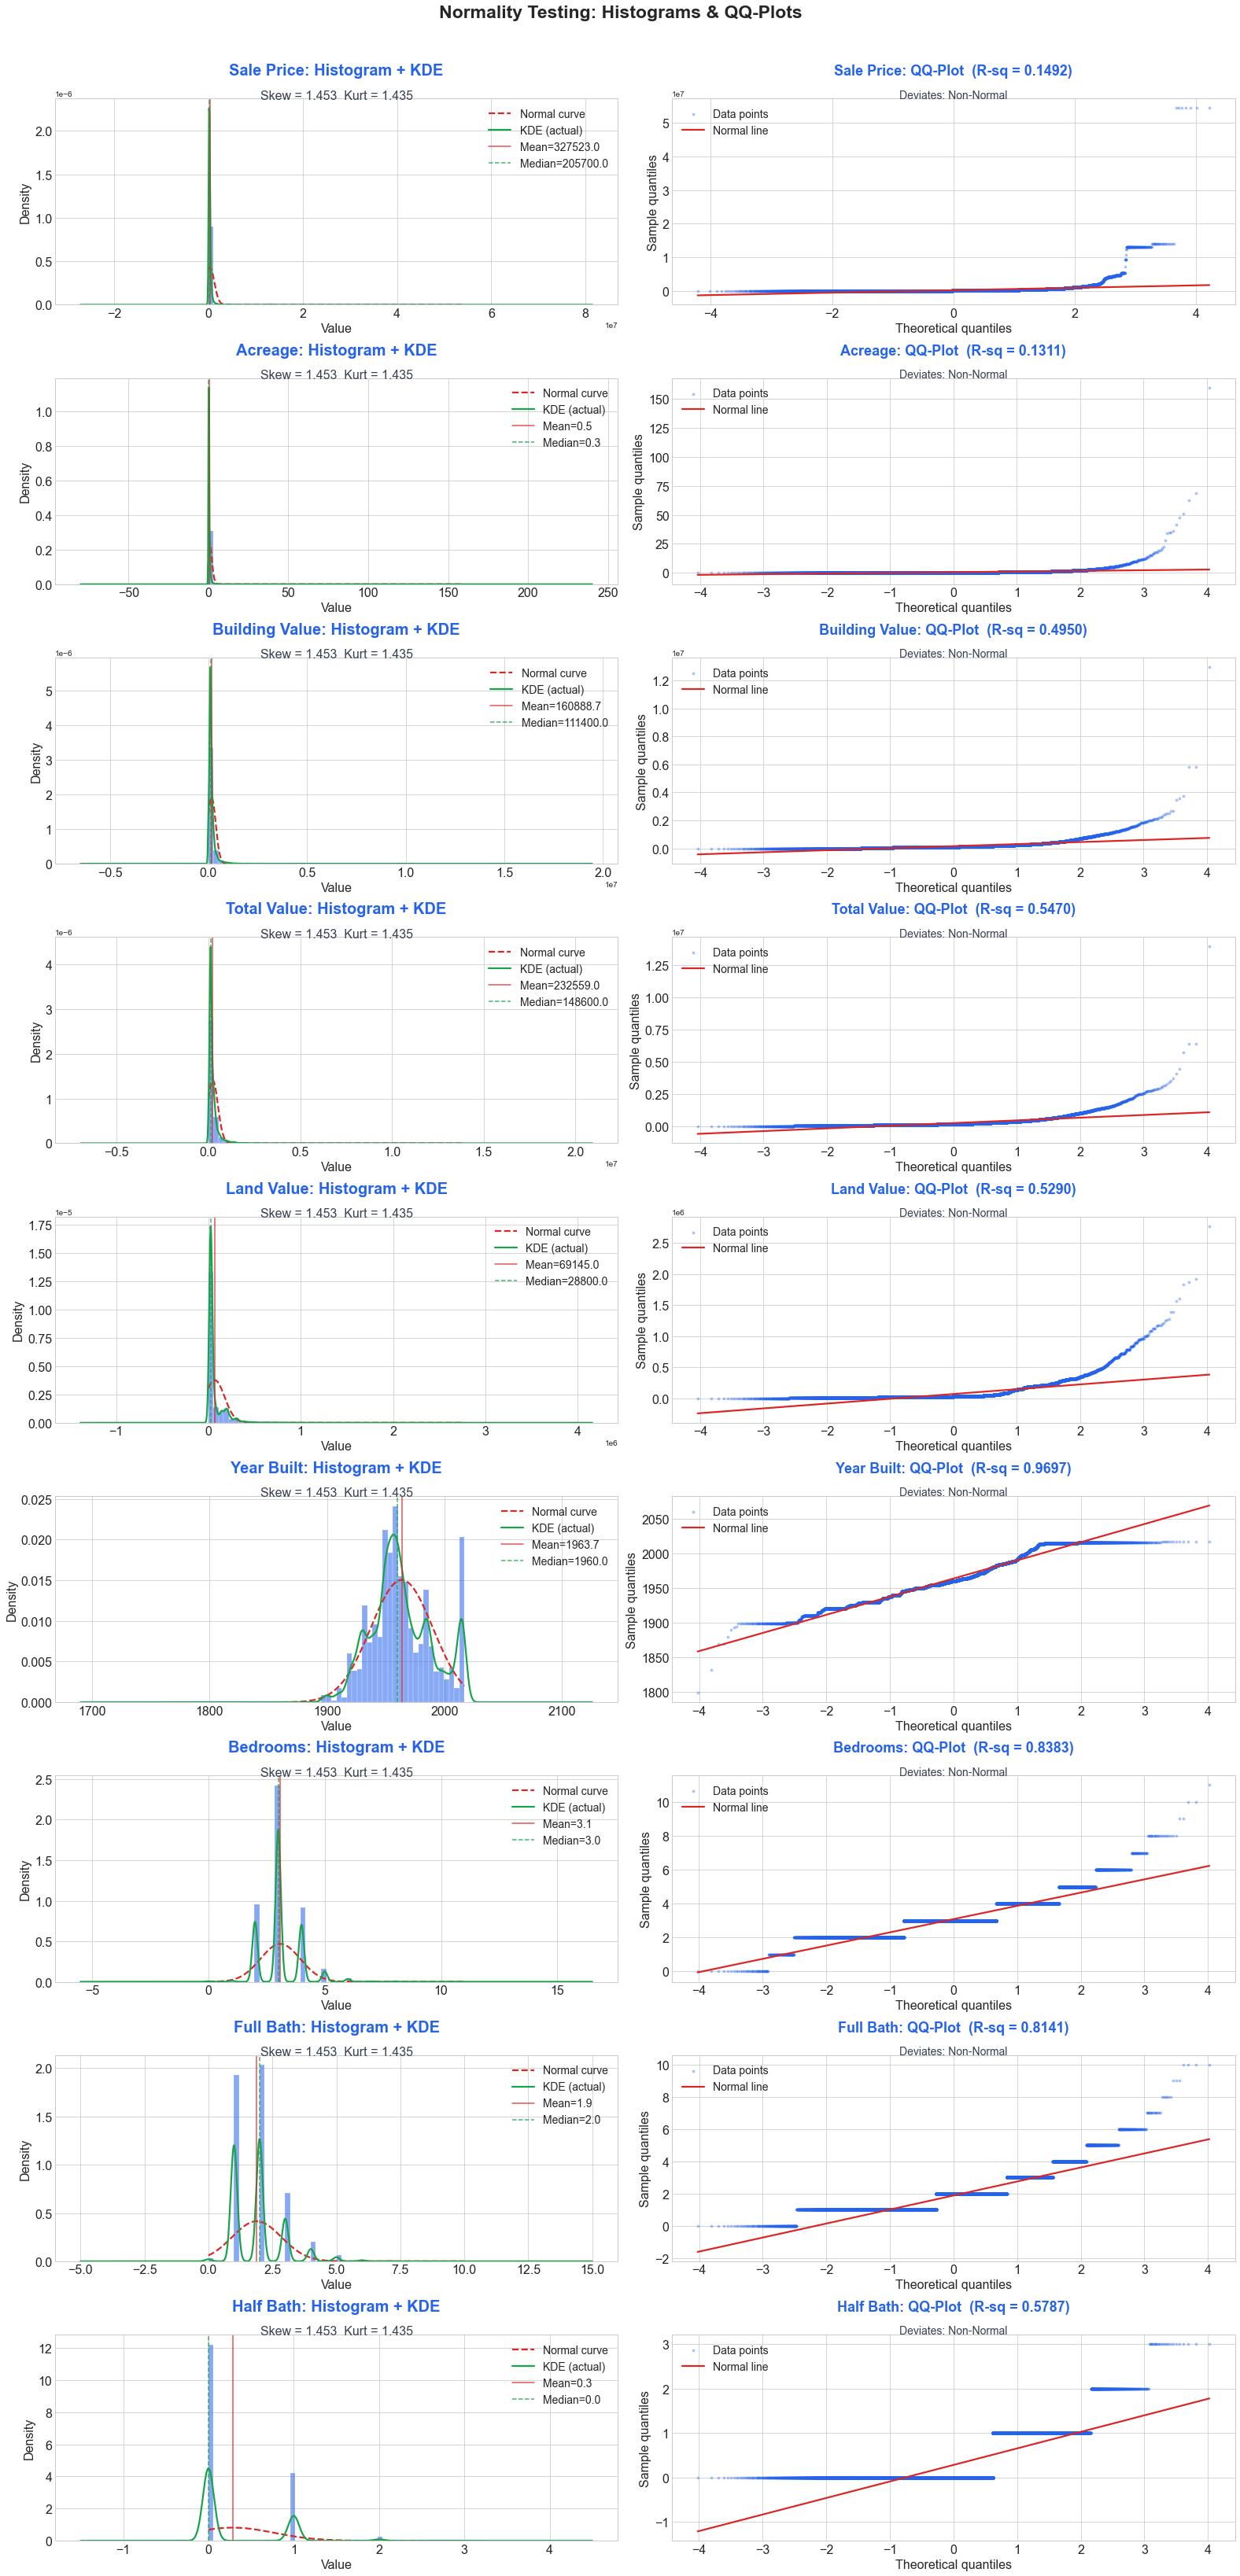

In [18]:
############# Histograms + KDE + QQ-Plots ##################

fig = plt.figure(figsize=(22, 5 * len(Numeric_Cols)))
fig.suptitle("Normality Testing: Histograms & QQ-Plots",
             fontsize=23, fontweight='bold', y=1.01)
 
for i, col in enumerate(Numeric_Cols):
    col_data = NH_data[col].dropna()          
    mu       = col_data.mean()
    sigma    = col_data.std()
 
    # Histogram + KDE + Normal curve 
    ax1 = fig.add_subplot(len(Numeric_Cols), 2, i * 2 + 1)
 
    
    ax1.hist(col_data, bins=50, color=PALETTE, alpha=0.55,
             density=True, edgecolor='white', linewidth=0.4)
 
    # Normal curve overlay (what the shape WOULD look like if normal)
    x = np.linspace(col_data.min(), col_data.max(), 300)
    normal_curve = stats.norm.pdf(x, mu, sigma)
    ax1.plot(x, normal_curve, color=ACCENT, linewidth=2.2,
             linestyle='--', label='Normal curve')
 
    # KDE: actual smoothed shape of this column only
    col_data.plot.kde(ax=ax1, color='#16A34A', linewidth=2.2,
                      label='KDE (actual)')
 
    # Mean and median lines
    ax1.axvline(mu, color=ACCENT,    linewidth=1.5,
                linestyle='-',  alpha=0.8, label=f'Mean={mu:.1f}')
    
    ax1.axvline(col_data.median(), color='#16A34A', linewidth=1.5,
                linestyle='--', alpha=0.8,
                label=f'Median={col_data.median():.1f}')
 
    ax1.set_title(
        f"{col}: Histogram + KDE\n"
        f"Skew = {skew_val:.3f}     Kurt = {kurt_val:.3f}",
        fontsize=18, fontweight='bold', color=PALETTE,
        pad=12, loc='center', linespacing=1.8
    )
    
    # Recolour only the second subtitle line to gray using the axes text objects
    ax1.title.set_color(PALETTE)   
 
    ax1.text(
        0.5, 1.045,
        f"Skew = {skew_val:.3f}  Kurt = {kurt_val:.3f}",
        transform=ax1.transAxes,
        fontsize=16, color='#374151',
        ha='center', va='top',
        fontweight='normal',
        clip_on=False
    )
    
    # Override the title to show only the column name (gray stats shown via annotate)
    ax1.set_title(
        f"{col}: Histogram + KDE",
        fontsize=20, fontweight='bold', color=PALETTE,
        pad=30, loc = 'center'                           # pad pushes title up to make room for annotate
    )
 
    ax1.set_xlabel("Value", fontsize=16)
    ax1.set_ylabel("Density", fontsize=16)
    ax1.tick_params(labelsize=16)
    ax1.legend(fontsize=14, loc='upper right')
 
    # QQ-Plot
    ax2 = fig.add_subplot(len(Numeric_Cols), 2, i * 2 + 2)
    (osm, osr), (slope, intercept, r) = stats.probplot(col_data, dist="norm")
    ax2.scatter(osm, osr, color=PALETTE, alpha=0.3,
                s=8, label='Data points')
    ref_x = np.array([min(osm), max(osm)])
    ax2.plot(ref_x, slope * ref_x + intercept,
             color=ACCENT, linewidth=2.2, label='Normal line')
 
    verdict_qq = 'Close to line - Normal' if r**2 > 0.99 else 'Deviates: Non-Normal'
    
    # QQ subtitle 
    ax2.text(
        0.5, 1.045,
        verdict_qq,
        transform=ax2.transAxes,
        fontsize=14, color='#374151',
        ha='center', va='top',
        fontweight='normal',
        clip_on=False
    )
    ax2.set_title(
        f"{col}: QQ-Plot  (R-sq = {r**2:.4f})",
        fontsize=18, fontweight='bold', color=PALETTE,
        pad=30, loc='center'
    )
 
    ax2.set_xlabel("Theoretical quantiles", fontsize=16)
    ax2.set_ylabel("Sample quantiles", fontsize=16)
    ax2.tick_params(labelsize=16)
    ax2.legend(fontsize=14)

    
plt.tight_layout()

plt.show()


### 5) Correlation 

In [19]:
corr_matrix = NH_data[Numeric_Cols].corr(method='spearman')

print(corr_matrix)

                Sale Price   Acreage  Building Value  Total Value  Land Value  \
Sale Price        1.000000  0.269861        0.642353     0.763199    0.751839   
Acreage           0.269861  1.000000        0.216204     0.299382    0.378826   
Building Value    0.642353  0.216204        1.000000     0.915763    0.606338   
Total Value       0.763199  0.299382        0.915763     1.000000    0.801966   
Land Value        0.751839  0.378826        0.606338     0.801966    1.000000   
Year Built       -0.057809  0.038423        0.113939     0.043376   -0.072863   
Bedrooms          0.360242  0.210420        0.465240     0.442384    0.320131   
Full Bath         0.465418  0.154223        0.619824     0.590095    0.414350   
Half Bath         0.178437  0.039197        0.304124     0.267859    0.151960   

                Year Built  Bedrooms  Full Bath  Half Bath  
Sale Price       -0.057809  0.360242   0.465418   0.178437  
Acreage           0.038423  0.210420   0.154223   0.039197  
Buildi

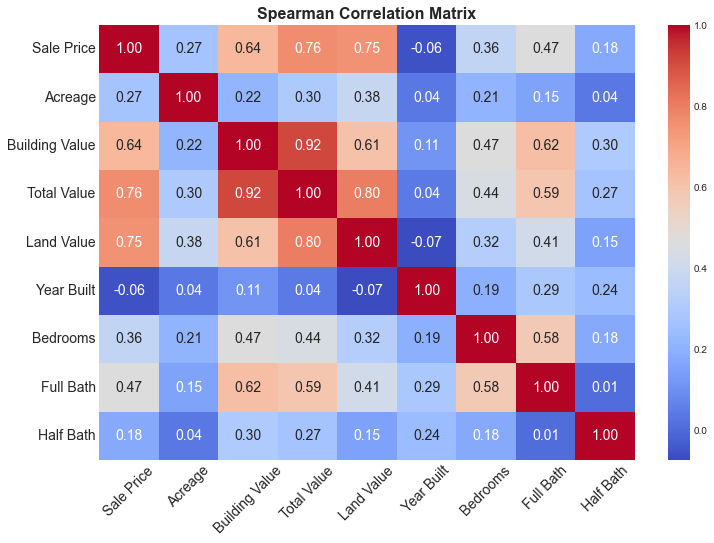

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 14})
plt.xticks(fontsize=14, rotation = 45)
plt.yticks(fontsize=14)
plt.title("Spearman Correlation Matrix", fontsize=16, fontweight = 'bold')
plt.show()

In [21]:
corr_pairs = corr_matrix.abs().unstack()

# Remove self-correlation
corr_pairs = corr_pairs[corr_pairs < 1]

corr_pairs = corr_pairs.sort_values(ascending=False)

print(corr_pairs.head(20))

Total Value     Building Value    0.915763
Building Value  Total Value       0.915763
Land Value      Total Value       0.801966
Total Value     Land Value        0.801966
Sale Price      Total Value       0.763199
Total Value     Sale Price        0.763199
Sale Price      Land Value        0.751839
Land Value      Sale Price        0.751839
Building Value  Sale Price        0.642353
Sale Price      Building Value    0.642353
Full Bath       Building Value    0.619824
Building Value  Full Bath         0.619824
Land Value      Building Value    0.606338
Building Value  Land Value        0.606338
Total Value     Full Bath         0.590095
Full Bath       Total Value       0.590095
Bedrooms        Full Bath         0.579226
Full Bath       Bedrooms          0.579226
                Sale Price        0.465418
Sale Price      Full Bath         0.465418
dtype: float64


### 6) Imputing Missing Values

In [22]:
def group_median_impute(NH_data, col, group_cols):
    """Fill NaN in col with median of group_cols combination; fallback to global median."""
    medians = NH_data.groupby(group_cols)[col].transform('median')
    global_median = NH_data[col].median()
    NH_data[col] = NH_data[col].fillna(medians).fillna(global_median)
    return NH_data
 
def group_mode_impute(NH_data, col, group_cols):
    """Fill NaN in col with mode of group_cols combination; fallback to global mode."""
    def safe_mode(s):
        m = s.mode()
        return m.iloc[0] if not m.empty else np.nan
    modes = NH_data.groupby(group_cols)[col].transform(safe_mode)
    global_mode = NH_data[col].mode().iloc[0]
    NH_data[col] = NH_data[col].fillna(modes).fillna(global_mode)
    return NH_data



In [23]:
NH_data.columns = NH_data.columns.str.strip()

In [24]:
# Before stats 
before = NH_data.isnull().sum()
# print(before)

In [25]:
# 1. Acreage: median by Land Use + City 
NH_data = group_median_impute(NH_data, 'Acreage', ['Land Use', 'Property City','Property Address_Street'])
 
# 2. Land Value: median by Land Use + City 
NH_data = group_median_impute(NH_data, 'Land Value', ['Land Use', 'Property City','Property Address_Street'])
 
# 3. Building Value: median by Land Use + City 
NH_data = group_median_impute(NH_data, 'Building Value', ['Land Use', 'Property City','Property Address_Street'])

In [26]:
# 4. Total Value: derive from Land + Building Value

'''mask_total = NH_data['Total Value'].isnull()
NH_data.loc[mask_total, 'Total Value'] = (
    NH_data.loc[mask_total, 'Land Value'] + NH_data.loc[mask_total, 'Building Value']
)'''
# Safety fallback
NH_data = group_median_impute(NH_data, 'Total Value', ['Land Use', 'Property City', 'Property Address_Street'])

In [27]:
# 5. Year Built: median by Land Use 
NH_data = group_median_impute(NH_data, 'Year Built', ['Land Use'])
NH_data['Year Built'] = NH_data['Year Built'].round().astype(int)
 
# 6. Bedrooms: mode by Land Use 
NH_data = group_mode_impute(NH_data, 'Bedrooms', ['Land Use'])
NH_data['Bedrooms'] = NH_data['Bedrooms'].round().astype(int)
 
# 7. Full Bath: mode by Land Use + Bedrooms 
#        Bedrooms is now complete, so we can use it as an additional grouper
NH_data = group_mode_impute(NH_data, 'Full Bath', ['Land Use', 'Bedrooms'])
NH_data['Full Bath'] = NH_data['Full Bath'].round().astype(int)
 
# 8. Half Bath: global mode (= 0)
NH_data['Half Bath'] = NH_data['Half Bath'].fillna(NH_data['Half Bath'].mode().iloc[0])
NH_data['Half Bath'] = NH_data['Half Bath'].round().astype(int)

In [28]:
# 9. Owner fields: label as Unknown
NH_data['Owner Name'] = NH_data['Owner Name'].fillna('Unknown')
NH_data['Owner Street Address'] = NH_data['Owner Street Address'].fillna('Unknown')
NH_data['Owner City Address'] = NH_data['Owner City Address'].fillna('Unknown')
NH_data['Owner State'] = NH_data['Owner State'].fillna('Unknown')

In [29]:
print(NH_data.columns.tolist())

['Row no.', 'UniqueID', 'ParcelID', 'Land Use', 'Sale Price', 'Legal Reference', 'Sold As Vacant', 'Owner Name', 'Acreage', 'TaxDistrict', 'Land Value', 'Building Value', 'Total Value', 'Year Built', 'Bedrooms', 'Full Bath', 'Half Bath', 'Sale Date', 'Property Address_Street', 'Property City', 'Owner Street Address', 'Owner City Address', 'Owner State']


In [30]:
# 10. Tax District
NH_data['TaxDistrict'] = NH_data['TaxDistrict'].fillna('Unknown')

In [31]:
NH_data.columns = NH_data.columns.str.strip()

In [32]:
after = NH_data.isnull().sum()

print("\n Imputation Summary")
print(f"{'Column':<25} {'Before':>8} {'After':>8} {'Filled':>8}")
print("─" * 55)
for col in before.index:
    b, a = before[col], after[col]
    if b > 0:
        print(f"{col:<25} {b:>8,} {a:>8,} {b-a:>8,}")
print("─" * 55)
print(f"Total missing before: {before.sum():,}")
print(f"Total missing after:  {after.sum():,}")


 Imputation Summary
Column                      Before    After   Filled
───────────────────────────────────────────────────────
Owner Name                  31,158        0   31,158
Acreage                     30,404        0   30,404
TaxDistrict                 30,404        0   30,404
Land Value                  30,404        0   30,404
Building Value              30,404        0   30,404
Total Value                 30,404        0   30,404
Year Built                  32,255        0   32,255
Bedrooms                    32,261        0   32,261
Full Bath                   32,143        0   32,143
Half Bath                   32,274        0   32,274
Owner Street Address        30,404        0   30,404
Owner City Address          30,404        0   30,404
Owner State                 30,404        0   30,404
───────────────────────────────────────────────────────
Total missing before: 403,323
Total missing after:  0


In [33]:
## Exporting data

out = r'C:\Users\hp\Desktop\Shreya\Datasets\Nashville Housing Missing Values Imputed Data.xlsx'
NH_data.to_excel(out, index=False)

-------------------------------------------------------------------------------------------------------------------------------
> Missing Value Imputation Strategy:
-------------------------------------------------------------------------------------------------------------------------------
First we plotted the distributions, checked the normality and derived correlation, to use the appropriate method for missing value imputation.

a) The dataset exhibited substantial missingness across several numeric and categorical variables, ranging from 53.9% to 57.3%      for key property attributes. Given this scale, imputation was performed using robust, distribution aware methods rather than    simple mean substitution.

b) For continuous monetary variables - Acreage, Land Value, and Building Value group-wise median imputation was applied,            stratified by Land Use category and Property City, Property Address Street. 
   These variables exhibited severe right skew (skewness ranging from 5.0 to 52.2), making the mean a poor representative of        central tendency as it is heavily distorted by extreme outliers. 
   
c) The median, being resistant to such outliers, provides a more stable and realistic estimate. Stratifying by Land Use and City    further ensures that imputed values reflect the natural variation across property types and locations, rather than applying a    single global statistic to fundamentally different property classes. 

d) Total Value, which is conceptually the sum of Land Value and Building Value, but was not derived using this additive            relationship rather it was derived using the group median by Land Use category and Property City, Property Address Street.

e) Year Built, while the closest to normality among all variables (QQ-plot R² = 0.97), still deviated sufficiently from a normal    distribution to warrant median rather than mean imputation. Group-wise median by Land Use was applied, as construction era      differs meaningfully between property types such as single-family homes, condominiums, and commercial properties.

f) For discrete count variables Bedrooms and Full Bath group-wise mode imputation was used, since these variables take only        integer values and their distributions are clearly categorical in nature. 
   Imputing a mean, which could yield non-integer values such as 2.7 bedrooms, would be analytically meaningless. 
   
g) Bedrooms was grouped by Land Use, while Full Bath was grouped by both Land Use and Bedrooms, as the number of bathrooms in a    property is closely tied to its size as measured by bedroom count. 
   Half Bath was imputed using the global mode, which is 0, as 73.3% of all observed values were zero and the variable showed      negligible correlation with all other predictors in the dataset, meaning no grouping variable meaningfully predicted its        presence.
   
h) Owner name and address fields were filled with the placeholder "Unknown" as these are administrative identifiers that carry      no predictive or analytical value in the modelling context.

i) TaxDistrict were filled with the placeholder "Unknown".


### 7) Validating Imputed Missing Values

In [34]:
original_data = pd.read_excel(r"C:\Users\hp\Desktop\Shreya\Datasets\SQL Results.xlsx")
data_clean = pd.read_excel(r"C:\Users\hp\Desktop\Shreya\Datasets\Nashville Housing Missing Values Imputed Data.xlsx")

In [35]:
print(data_clean.isnull().sum())

Row no.                    0
UniqueID                   0
ParcelID                   0
Land Use                   0
Sale Price                 0
Legal Reference            0
Sold As Vacant             0
Owner Name                 0
Acreage                    0
TaxDistrict                0
Land Value                 0
Building Value             0
Total Value                0
Year Built                 0
Bedrooms                   0
Full Bath                  0
Half Bath                  0
Sale Date                  0
Property Address_Street    0
Property City              0
Owner Street Address       0
Owner City Address         0
Owner State                0
dtype: int64


In [36]:
diff = data_clean['Total Value'] - original_data['Total Value']

negative_count = (diff < 0).sum()
positive_count = (diff > 0).sum()

print(f"Negative Difference Rows: {negative_count}")
print(f"Positive Difference Rows: {positive_count}")

Negative Difference Rows: 12857
Positive Difference Rows: 12527


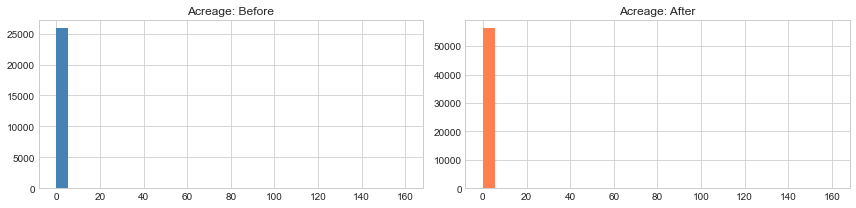

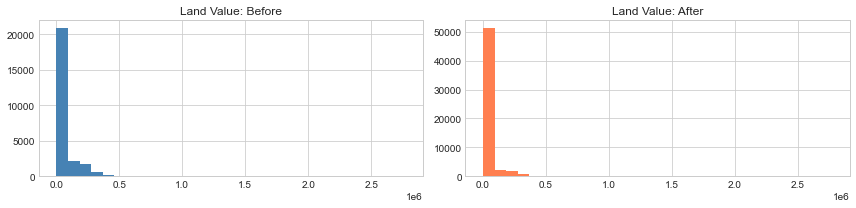

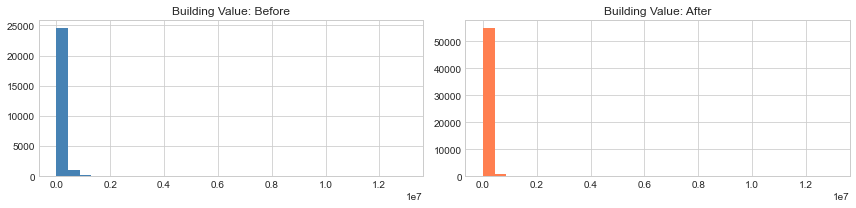

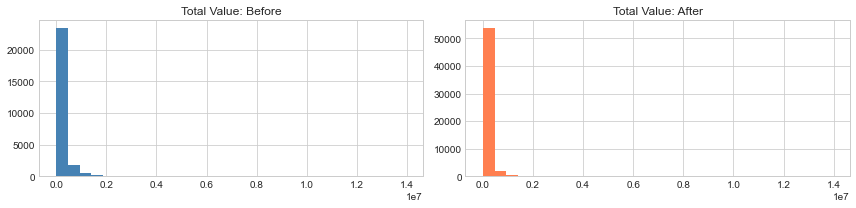

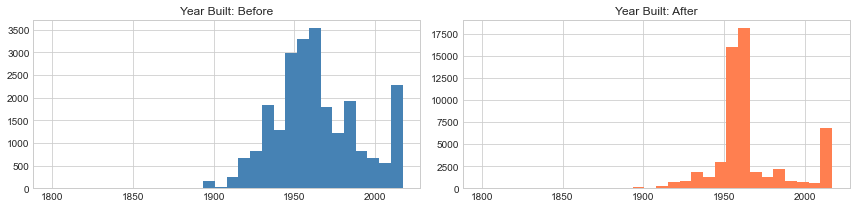

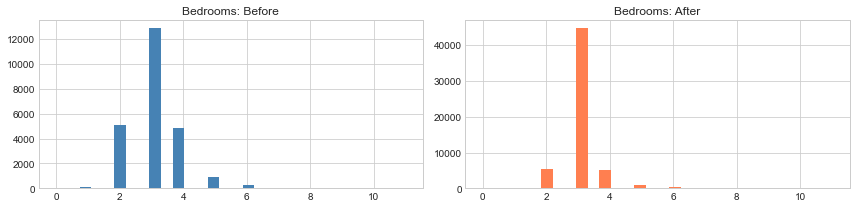

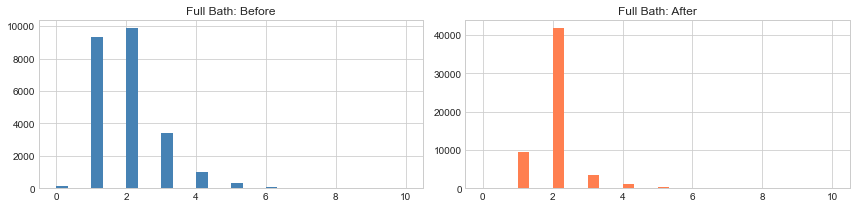

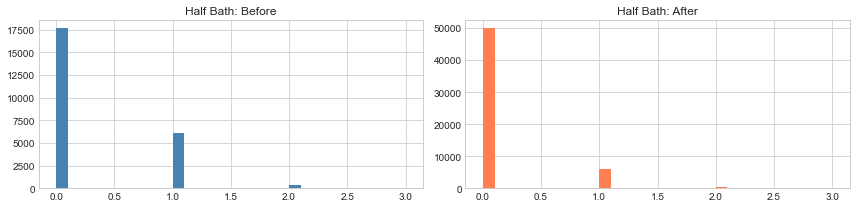

In [37]:
import matplotlib.pyplot as plt
cols = ['Acreage', 'Land Value', 'Building Value', 'Total Value', 'Year Built', 'Bedrooms', 'Full Bath', 'Half Bath']
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    original_data[col].dropna().hist(ax=axes[0], bins=30, color='steelblue')
    axes[0].set_title(f'{col}: Before')
    
    data_clean[col].hist(ax=axes[1], bins=30, color='coral')
    axes[1].set_title(f'{col}: After')
    plt.tight_layout()
    plt.show()

--------------------------------------------------------------------------------------------------------------------------------
The before and after distributions follow the same shape.   
The difference in frequency count is expected since missing values were filled. The extreme skewness visible in both plots is likely driven by outliers, which is why the next step is outlier detection and treatment


### 8) Outlier Detection

IQR OUTLIER DETECTION
        Column  Lower Bound  Upper Bound  Outlier Count  Outlier %
       Acreage         0.27         0.27          25235      44.76
    Land Value     28800.00     28800.00          25920      45.98
Building Value    111400.00    111400.00          25957      46.05
   Total Value    148600.00    148600.00          25960      46.05
    Year Built      1944.50      1980.50          16133      28.62
      Bedrooms         3.00         3.00          11690      20.74
     Full Bath         2.00         2.00          14608      25.91
     Half Bath         0.00         0.00           6448      11.44
    Sale Price   -156000.00    620000.00           4119       7.31


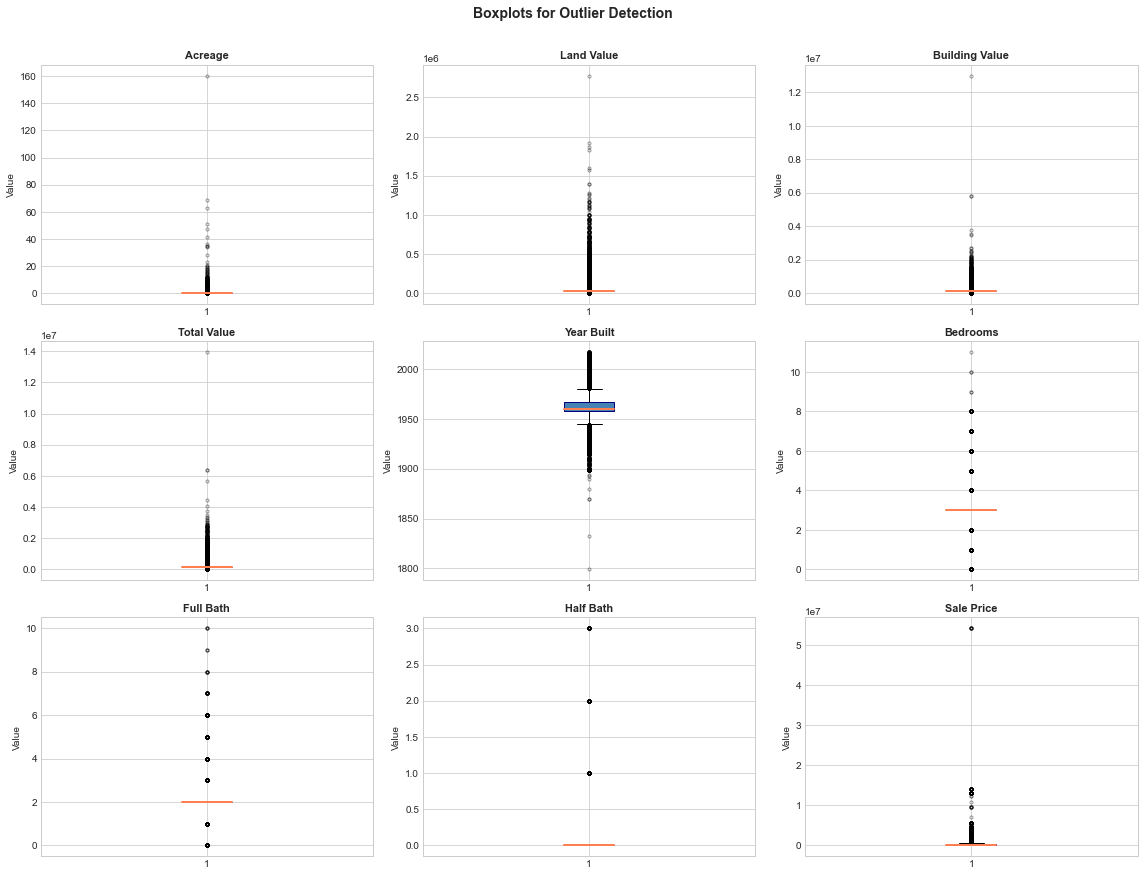


Outlier rows for 'Sale Price': 4119
     UniqueID  Sale Price
711     31108      900000
712     31109      900000
713     31110      900000
714     31111      900000
715     31112      900000
716     31113      900000
718     31114      900000
719     31115      900000
720     43099      877500
721     31116      900000


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


num_cols = ['Acreage', 'Land Value', 'Building Value', 'Total Value',
            'Year Built', 'Bedrooms', 'Full Bath', 'Half Bath', 'Sale Price']


# METHOD 1: IQR (Interquartile Range) Method

print("=" * 60)
print("IQR OUTLIER DETECTION")
print("=" * 60)

iqr_summary = []

for col in num_cols:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data_clean[(data_clean[col] < lower) | (data_clean[col] > upper)]
    iqr_summary.append({
        'Column': col,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Bound': lower, 'Upper Bound': upper,
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(data_clean) * 100, 2)
    })

iqr_df = pd.DataFrame(iqr_summary)
print(iqr_df[['Column', 'Lower Bound', 'Upper Bound', 'Outlier Count', 'Outlier %']].to_string(index=False))



# Visualisation: Boxplots for all numeric cols

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(data_clean[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='coral', linewidth=2),
                    flierprops=dict(marker='o', color='red', alpha=0.4, markersize=3))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots for Outlier Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# Extract actual outlier rows (IQR)
col = 'Sale Price'
Q1 = data_clean[col].quantile(0.25)
Q3 = data_clean[col].quantile(0.75)
IQR = Q3 - Q1
outlier_rows = data_clean[(data_clean[col] < Q1 - 1.5 * IQR) | (data_clean[col] > Q3 + 1.5 * IQR)]
print(f"\nOutlier rows for '{col}': {len(outlier_rows)}")
print(outlier_rows[['UniqueID', col]].head(10))

### 9) Treating Outliers

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fix messy category names 
data_clean['Land Use'] = data_clean['Land Use'].str.strip()
data_clean['Land Use'] = data_clean['Land Use'].str.replace(r'\s+', ' ', regex=True)  # collapse extra spaces
data_clean['Land Use'] = data_clean['Land Use'].str.replace('\n', ' ', regex=False)   # remove newlines

print("Shape before treatment:", data_clean.shape)
print(data_clean['Land Use'].value_counts())


Shape before treatment: (56373, 23)
SINGLE FAMILY                                 34119
RESIDENTIAL CONDO                             14064
VACANT RESIDENTIAL LAND                        3540
VACANT RES LAND                                1549
DUPLEX                                         1372
ZERO LOT LINE                                  1047
CONDO                                           247
RESIDENTIAL COMBO/MISC                           95
TRIPLEX                                          92
QUADPLEX                                         39
CONDOMINIUM OFC OR OTHER COM CONDO               35
CHURCH                                           33
MOBILE HOME                                      20
DORMITORY/BOARDING HOUSE                         19
VACANT COMMERCIAL LAND                           17
SPLIT CLASS                                      17
PARKING LOT                                      11
FOREST                                           10
GREENBELT                   

#### (i) Percentile Winsorization (cap at 1st and 99th percentile) for: Acreage, Sale Price, Land Value, Building Value, Total Value

--------------------------------------------------------------------------------------------------------------------------------
> Percentile based Winsorization:

- It identifies the bottom 1% (quantile(0.01)) and the top 1% (quantile(0.99)) of the data.

- It uses .clip(), which takes any value smaller than the 1st percentile and drags it up to that value, and any value higher    than the 99th percentile and caps it at that value. 

- It limits the influence of extreme outliers (like a massive estate or a tiny plot of land) without deleting the rows entirely.
--------------------------------------------------------------------------------------------------------------------------------

Unlike Trimming (which deletes the outliers), Winsorization keeps the outliers but modifies their values. This preserves the sample size while preventing extreme values from skewing statistical measures like the mean or standard deviation.

In [40]:
# STRATEGY 1: 
winsor_cols = ['Acreage', 'Sale Price', 'Land Value', 'Building Value', 'Total Value']

print("\n----Strategy 1: Winsorization ---")
for col in winsor_cols:
    lower = data_clean[col].quantile(0.01)
    upper = data_clean[col].quantile(0.99)
    before = ((data_clean[col] < lower) | (data_clean[col] > upper)).sum()
    data_clean[col] = data_clean[col].clip(lower=lower, upper=upper)
    print(f"{col:20s}: capped {before} values  |  new range: [{data_clean[col].min():.1f}, {data_clean[col].max():.1f}]")


----Strategy 1: Winsorization ---
Acreage             : capped 837 values  |  new range: [0.1, 2.1]
Sale Price          : capped 1107 values  |  new range: [24358.0, 1935000.0]
Land Value          : capped 1034 values  |  new range: [10500.0, 350000.0]
Building Value      : capped 564 values  |  new range: [0.0, 719764.0]
Total Value         : capped 1117 values  |  new range: [15000.0, 1014200.0]


#### (ii) Domain-based cap by Land Use for: Bedrooms, Full Bath, Half Bath

In [41]:

print("\n--- Strategy 2: Land-Use-Aware Domain Caps ---")

land_use_caps = {

    # Residential: single unit 
    'SINGLE FAMILY'     : {'Bedrooms': 7,  'Full Bath': 5,  'Half Bath': 3},
    'ZERO LOT LINE'     : {'Bedrooms': 5,  'Full Bath': 4,  'Half Bath': 2},
    'MOBILE HOME'       : {'Bedrooms': 4,  'Full Bath': 3,  'Half Bath': 2},
    'PARSONAGE'         : {'Bedrooms': 6,  'Full Bath': 4,  'Half Bath': 2},

    # Residential: condos 
    'RESIDENTIAL CONDO' : {'Bedrooms': 5,  'Full Bath': 4,  'Half Bath': 2},
    'CONDO'             : {'Bedrooms': 5,  'Full Bath': 4,  'Half Bath': 2},
    'CONDOMINIUM OFC OR OTHER COM CONDO': {'Bedrooms': 3, 'Full Bath': 3, 'Half Bath': 2},

    # Residential: multi-unit 
    'DUPLEX'            : {'Bedrooms': 10, 'Full Bath': 8,  'Half Bath': 4},
    'TRIPLEX'           : {'Bedrooms': 12, 'Full Bath': 10, 'Half Bath': 5},
    'QUADPLEX'          : {'Bedrooms': 14, 'Full Bath': 12, 'Half Bath': 6},
    'RESIDENTIAL COMBO/MISC'            : {'Bedrooms': 10, 'Full Bath': 8,  'Half Bath': 4},
    'SPLIT CLASS'       : {'Bedrooms': 10, 'Full Bath': 8,  'Half Bath': 4},
    'VACANT ZONED MULTI FAMILY'         : {'Bedrooms': 0,  'Full Bath': 0,  'Half Bath': 0},
    'APARTMENT: LOW RISE (BUILT SINCE 1960)': {'Bedrooms': 6, 'Full Bath': 4, 'Half Bath': 2},
    'DORMITORY/BOARDING HOUSE'          : {'Bedrooms': 20, 'Full Bath': 15, 'Half Bath': 5},

    # Vacant land (all variants + typo) → must be zero 
    'VACANT RESIDENTIAL LAND'           : {'Bedrooms': 0,  'Full Bath': 0,  'Half Bath': 0},
    'VACANT RES LAND'                   : {'Bedrooms': 0,  'Full Bath': 0,  'Half Bath': 0},
    'VACANT RESIENTIAL LAND'            : {'Bedrooms': 0,  'Full Bath': 0,  'Half Bath': 0},
    'VACANT COMMERCIAL LAND'            : {'Bedrooms': 0,  'Full Bath': 0,  'Half Bath': 0},
    'VACANT RURAL LAND'                 : {'Bedrooms': 0,  'Full Bath': 0,  'Half Bath': 0},
    'GREENBELT'                         : {'Bedrooms': 0,  'Full Bath': 0,  'Half Bath': 0},
    'GREENBELT/RES GRRENBELT/RES'       : {'Bedrooms': 0,  'Full Bath': 0,  'Half Bath': 0},
    'FOREST'                            : {'Bedrooms': 0,  'Full Bath': 0,  'Half Bath': 0},
    'PARKING LOT'                       : {'Bedrooms': 0,  'Full Bath': 0,  'Half Bath': 0},

    # Non-residential: no bedrooms expected 
    'CHURCH'                            : {'Bedrooms': 0,  'Full Bath': 5,  'Half Bath': 3},
    'MORTUARY/CEMETERY'                 : {'Bedrooms': 0,  'Full Bath': 2,  'Half Bath': 1},
    'NON-PROFIT CHARITABLE SERVICE'     : {'Bedrooms': 0,  'Full Bath': 5,  'Half Bath': 3},
    'DAY CARE CENTER'                   : {'Bedrooms': 0,  'Full Bath': 5,  'Half Bath': 3},
    'OFFICE BLDG (ONE OR TWO STORIES)'  : {'Bedrooms': 0,  'Full Bath': 8,  'Half Bath': 4},
    'SMALL SERVICE SHOP'                : {'Bedrooms': 0,  'Full Bath': 4,  'Half Bath': 2},
    'CONVENIENCE MARKET WITHOUT GAS'    : {'Bedrooms': 0,  'Full Bath': 4,  'Half Bath': 2},
    'RESTURANT/CAFETERIA'               : {'Bedrooms': 0,  'Full Bath': 6,  'Half Bath': 3},
    'STRIP SHOPPING CENTER'             : {'Bedrooms': 0,  'Full Bath': 8,  'Half Bath': 4},
    'ONE STORY GENERAL RETAIL STORE'    : {'Bedrooms': 0,  'Full Bath': 4,  'Half Bath': 2},
    'LIGHT MANUFACTURING'               : {'Bedrooms': 0,  'Full Bath': 6,  'Half Bath': 3},
    'TERMINAL/DISTRIBUTION WAREHOUSE'   : {'Bedrooms': 0,  'Full Bath': 4,  'Half Bath': 2},
    'CLUB/UNION HALL/LODGE'             : {'Bedrooms': 5,  'Full Bath': 6,  'Half Bath': 3},
    'NIGHTCLUB/LOUNGE'                  : {'Bedrooms': 0,  'Full Bath': 6,  'Half Bath': 3},
    'METRO OTHER THAN OFC, SCHOOL,HOSP, OR PARK': {'Bedrooms': 0, 'Full Bath': 8, 'Half Bath': 4},
}




--- Strategy 2: Land-Use-Aware Domain Caps ---


In [42]:
for land_use, caps in land_use_caps.items():
    mask = data_clean['Land Use'] == land_use
    if mask.sum() == 0:
        continue
    for col, max_val in caps.items():
        flagged = (data_clean.loc[mask, col] > max_val).sum()
        data_clean.loc[mask, col] = data_clean.loc[mask, col].clip(upper=max_val)
        if flagged > 0:
            print(f"{land_use:45s} | {col:10s}: capped {flagged} values above {max_val}")

# Fallback for any remaining unlisted Land Use types
known = list(land_use_caps.keys())
unlisted_mask = ~data_clean['Land Use'].isin(known)
if unlisted_mask.sum() > 0:
    print(f"\nUnlisted Land Use types still found:")
    print(data_clean.loc[unlisted_mask, 'Land Use'].value_counts())
    print("Applying fallback global cap...")
    
    for col, max_val in [('Bedrooms', 10), ('Full Bath', 8), ('Half Bath', 4)]:
        flagged = (data_clean.loc[unlisted_mask, col] > max_val).sum()
        data_clean.loc[unlisted_mask, col] = data_clean.loc[unlisted_mask, col].clip(upper=max_val)
        if flagged > 0:
            print(f"{'Fallback':45s} | {col:10s} → capped {flagged} values above {max_val}")

SINGLE FAMILY                                 | Bedrooms  : capped 8 values above 7
SINGLE FAMILY                                 | Full Bath : capped 102 values above 5
ZERO LOT LINE                                 | Bedrooms  : capped 1 values above 5
VACANT ZONED MULTI FAMILY                     | Bedrooms  : capped 2 values above 0
VACANT ZONED MULTI FAMILY                     | Full Bath : capped 2 values above 0
VACANT RESIDENTIAL LAND                       | Bedrooms  : capped 3530 values above 0
VACANT RESIDENTIAL LAND                       | Full Bath : capped 3438 values above 0
VACANT RESIDENTIAL LAND                       | Half Bath : capped 175 values above 0
VACANT RES LAND                               | Bedrooms  : capped 1547 values above 0
VACANT RES LAND                               | Full Bath : capped 1532 values above 0
VACANT RES LAND                               | Half Bath : capped 151 values above 0
VACANT RESIENTIAL LAND                        | Bedrooms  

#### (iii) Year Built: drop clearly erroneous rows Keep only realistic range: 1830–2024

In [43]:
# STRATEGY 3: 
print("\n--- Strategy 3: Year Built Filter ---")
before_yr = len(data_clean)
data_clean = data_clean[(data_clean['Year Built'] >= 1830) & (data_clean['Year Built'] <= 2024)]
dropped = before_yr - len(data_clean)
print(f"{'Year Built':20s}: dropped {dropped} rows outside [1830, 2024]")

print("\nShape after treatment:", data_clean.shape)



--- Strategy 3: Year Built Filter ---
Year Built          : dropped 1 rows outside [1830, 2024]

Shape after treatment: (56372, 23)


#### (iv) Visualize: Before vs After

In [44]:
df_orig = pd.read_excel(r"C:\Users\hp\Desktop\Shreya\Datasets\Nashville Housing Missing Values Imputed Data.xlsx")

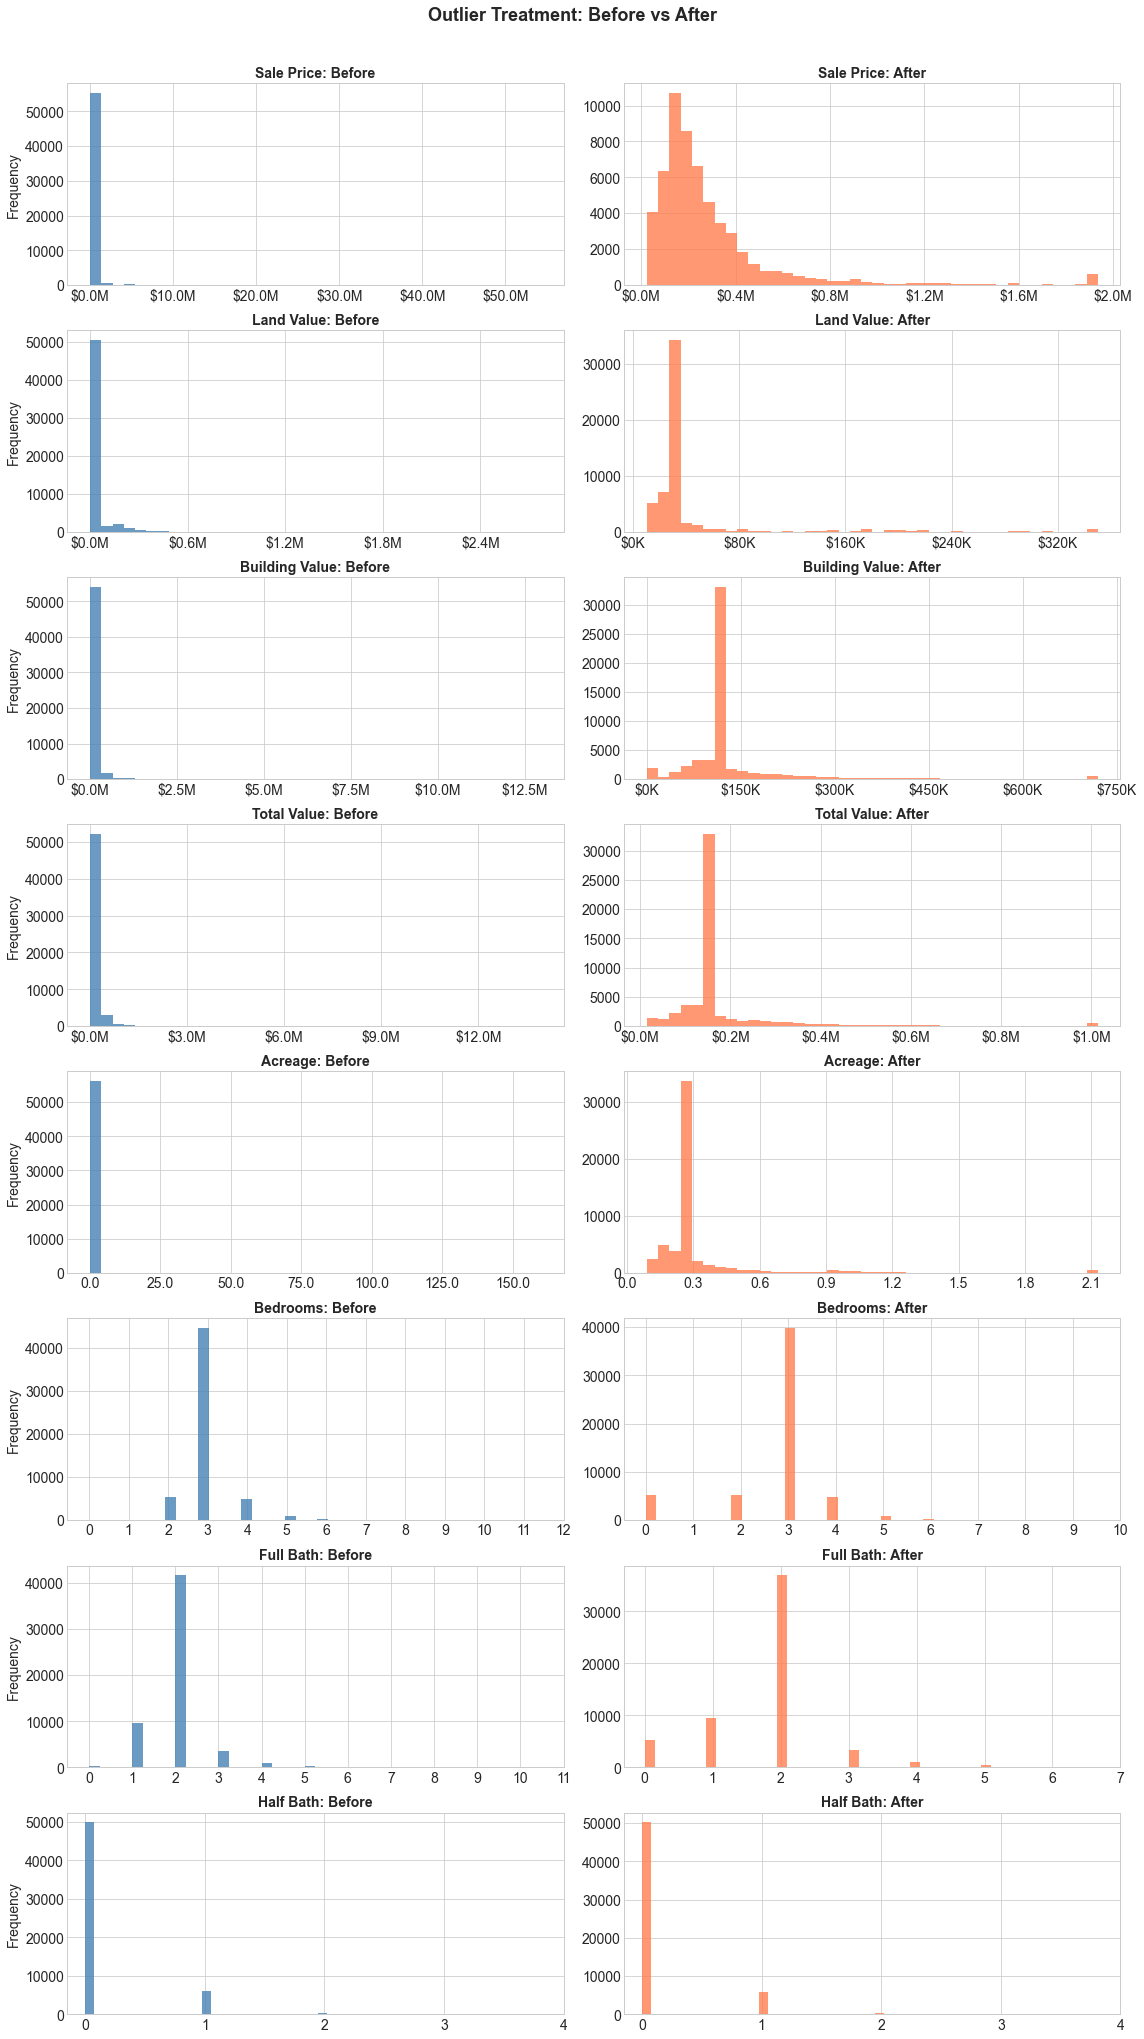

In [45]:
import matplotlib.ticker as mticker

# Define formatting per column type
money_cols    = ['Sale Price', 'Land Value', 'Building Value', 'Total Value']
decimal_cols  = ['Acreage']
integer_cols  = ['Bedrooms', 'Full Bath', 'Half Bath']
plot_cols = money_cols + decimal_cols + integer_cols

def format_axis(ax, col, data):
    """Apply the right x-axis formatter and tick count for each column type."""

    if col in money_cols:
        # Show as $K or $M depending on range
        max_val = data.max()
        if max_val >= 1_000_000:
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
            )
        else:
            ax.xaxis.set_major_formatter(
                mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
            )
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
        ax.tick_params(axis='x')

    elif col in decimal_cols:
        # Show up to 2 decimal places, limit ticks
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:.1f}')
        )
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=8))
        ax.tick_params(axis='x')

    elif col in integer_cols:
        # Force whole number ticks only — no decimals between integers
        max_val = int(data.max())
        ax.set_xticks(range(0, max_val + 2))
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{int(x)}')
        )
        ax.tick_params(axis='x')



fig, axes = plt.subplots(len(plot_cols), 2, figsize=(16, len(plot_cols) * 3.5))


for i, col in enumerate(plot_cols):

    data_before = df_orig[col].dropna()
    data_after  = data_clean[col].dropna()

    # BEFORE
    axes[i, 0].hist(data_before, bins=40, color='steelblue', alpha=0.8)
    axes[i, 0].set_title(f'{col}: Before', fontweight='bold', fontsize=14)
    axes[i, 0].set_ylabel('Frequency', fontsize=14)
    axes[i,0].tick_params(labelsize=14)
    format_axis(axes[i, 0], col, data_before)
    

    # AFTER 
    axes[i, 1].hist(data_after, bins=40, color='coral', alpha=0.8)
    axes[i, 1].set_title(f'{col}: After', fontweight='bold', fontsize=14)
    axes[i,1].tick_params(labelsize=14)
    format_axis(axes[i, 1], col, data_after)

plt.suptitle('Outlier Treatment: Before vs After', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [46]:
# 1. Check the Building Value spike at ~$100K
print(data_clean[data_clean['Building Value'].between(90000, 110000)]['Land Use'].value_counts())


SINGLE FAMILY               3314
DUPLEX                       185
ZERO LOT LINE                 82
TRIPLEX                       19
VACANT RESIDENTIAL LAND       15
VACANT RES LAND                8
QUADPLEX                       8
DORMITORY/BOARDING HOUSE       2
RESIDENTIAL COMBO/MISC         2
SPLIT CLASS                    2
MOBILE HOME                    2
Name: Land Use, dtype: int64


-------------------------------------------------------------------------------------------------------------------------------
3,314 Single Family properties have building value between $90K-$110K. It's simply the most common building value range for Nashville residential properties. The spike is real data, not an artifact.


In [47]:
# 2. Check why Bedrooms distribution shifted so much
print("Before caps:")
print(df_orig['Bedrooms'].value_counts().sort_index())
print("\nAfter caps:")
print(data_clean['Bedrooms'].value_counts().sort_index())

Before caps:
0        53
1       102
2      5304
3     44683
4      5036
5       870
6       258
7        35
8        27
9         2
10        2
11        1
Name: Bedrooms, dtype: int64

After caps:
0     5206
1      101
2     5271
3    39778
4     4873
5      830
6      249
7       41
8       22
9        1
Name: Bedrooms, dtype: int64


In [48]:
# 3. Check the isolated far-right bar in Land Value
print(data_clean[data_clean['Land Value'] > 300000][['Land Use', 'Land Value']].head(10))

                      Land Use  Land Value
3330           VACANT RES LAND    315700.0
4135             SINGLE FAMILY    350000.0
4243   VACANT RESIDENTIAL LAND    350000.0
4244   VACANT RESIDENTIAL LAND    350000.0
8057   VACANT RESIDENTIAL LAND    350000.0
11657  VACANT RESIDENTIAL LAND    350000.0
11658  VACANT RESIDENTIAL LAND    350000.0
14471            SINGLE FAMILY    312500.0
14472            SINGLE FAMILY    312500.0
14473            SINGLE FAMILY    312500.0


#### (v) Summary Report

In [49]:

print("\n========== OUTLIER TREATMENT SUMMARY ==========")
print(f"Original rows   : {len(original_data)}")
print(f"Treated rows    : {len(data_clean)}")
print(f"Rows dropped    : {len(original_data) - len(data_clean)} (Year Built filter only)")
print(f"Columns treated : {plot_cols}")
print("================================================")


========== OUTLIER TREATMENT SUMMARY ==========
Original rows   : 56373
Treated rows    : 56372
Rows dropped    : 1 (Year Built filter only)
Columns treated : ['Sale Price', 'Land Value', 'Building Value', 'Total Value', 'Acreage', 'Bedrooms', 'Full Bath', 'Half Bath']


#### (vi)Boxplots: Before and After

In [50]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np


# Column groups for formatting

money_cols   = ['Sale Price', 'Land Value', 'Building Value', 'Total Value']
decimal_cols = ['Acreage']
integer_cols = ['Bedrooms', 'Full Bath', 'Half Bath']
plot_cols    = money_cols + decimal_cols + integer_cols


# Y-axis formatter (boxplots are vertical so values on y-axis)

def format_yaxis(ax, col, data):
    if col in money_cols:
        max_val = data.max()
        if max_val >= 1_000_000:
            ax.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')
            )
        else:
            ax.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K')
            )
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))

    elif col in decimal_cols:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:.1f}')
        )
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8))

    elif col in integer_cols:
        max_val = int(data.max())
        ax.set_yticks(range(0, max_val + 2))
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{int(x)}')
        )


# Boxplot styling helper

def styled_boxplot(ax, data, color):
    bp = ax.boxplot(
        data.dropna(),
        vert=True,
        patch_artist=True,
        widths=0.5,
        boxprops      = dict(facecolor=color, color='black', alpha=0.7),
        medianprops   = dict(color='black', linewidth=2),
        whiskerprops  = dict(color='black', linewidth=1.2),
        capprops      = dict(color='black', linewidth=1.5),
        flierprops    = dict(
            marker='o', color=color, alpha=0.3,
            markersize=3, markeredgewidth=0.5
        )
    )
    return bp


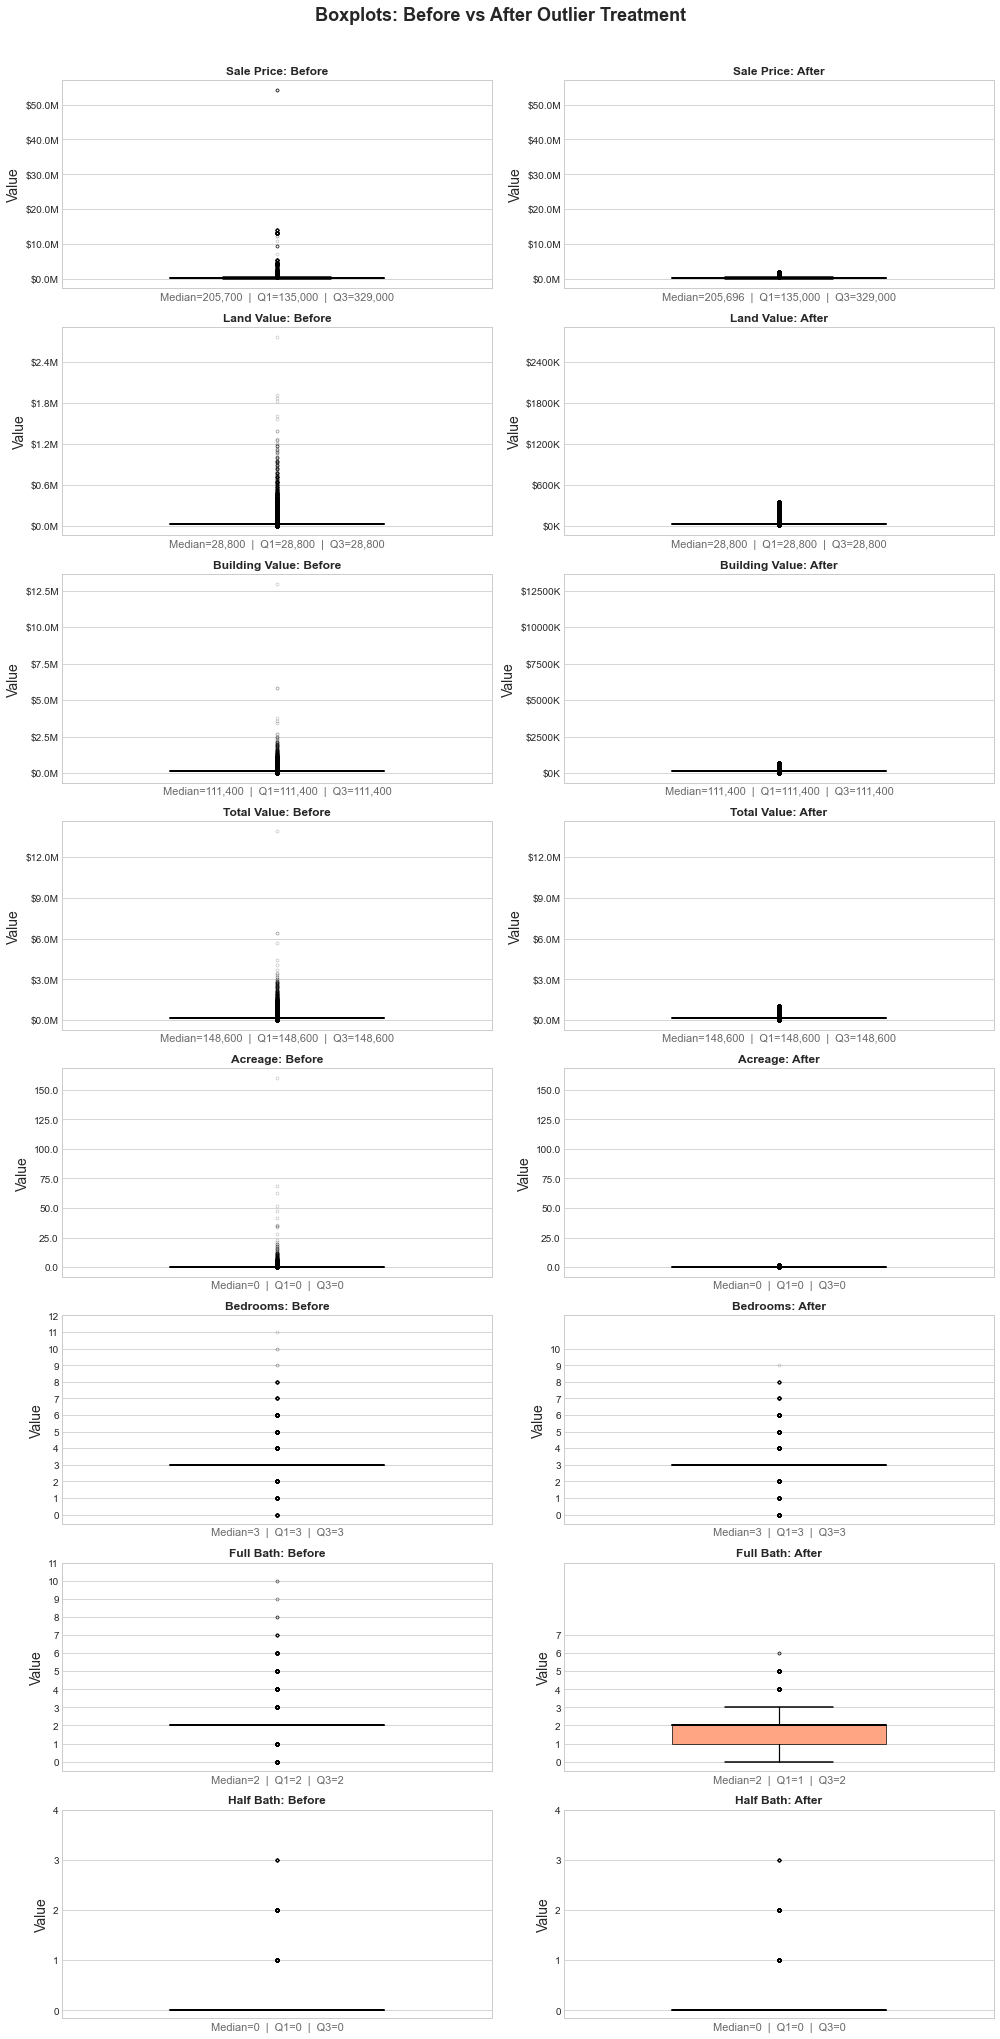

In [51]:
# Plot: Before vs After Boxplots


fig, axes = plt.subplots(len(plot_cols), 2, figsize=(14, len(plot_cols) * 3.5))

for i, col in enumerate(plot_cols):

    data_before = df_orig[col].dropna()
    data_after  = data_clean[col].dropna()

    # BEFORE
    styled_boxplot(axes[i, 0], data_before, color='steelblue')
    axes[i, 0].set_title(f'{col}: Before', fontweight='bold')
    axes[i, 0].set_ylabel('Value', fontsize = 14)
    axes[i, 0].set_xticks([])                        # hide x tick (only 1 box)
    format_yaxis(axes[i, 0], col, data_before)

    # Annotate key stats
    q1  = data_before.quantile(0.25)
    q3  = data_before.quantile(0.75)
    med = data_before.median()
    axes[i, 0].set_xlabel(
        f'Median={med:,.0f}  |  Q1={q1:,.0f}  |  Q3={q3:,.0f}',
        fontsize=11, color='dimgray'
    )

    # AFTER
    styled_boxplot(axes[i, 1], data_after, color='coral')
    axes[i, 1].set_title(f'{col}: After', fontweight='bold')
    axes[i, 1].set_ylabel('Value', fontsize = 14)
    axes[i, 1].set_xticks([])
    axes[i, 1].set_ylim(axes[i, 0].get_ylim())
    format_yaxis(axes[i, 1], col, data_after)

    # Annotate key stats
    q1  = data_after.quantile(0.25)
    q3  = data_after.quantile(0.75)
    med = data_after.median()
    axes[i, 1].set_xlabel(
        f'Median={med:,.0f}  |  Q1={q1:,.0f}  |  Q3={q3:,.0f}',
        fontsize=11, color='dimgray'
    )

plt.suptitle('Boxplots: Before vs After Outlier Treatment',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

From the above visualizations it is clear that there is a considerable reduction in the outliers. There are still outliers but those are natural.

In [52]:
# SAVE

out1 = r'C:\Users\hp\Desktop\Shreya\Datasets\Nashville Housing Cleaned Data.xlsx'
data_clean.to_excel(out1, index=False)